# Neural PDE Laboratory · 01
## Membranes, PINNs, Deep Ritz and boundary conditions

Experiments **1–3** of the laboratory. This notebook is self-contained:
run it in a fresh kernel; no earlier notebook or saved result is required.

[All seven notebooks](Neural_PDE_Laboratory.ipynb) · [Setup and guide](NOTEBOOK_README.md)

Install `experiments/requirements-notebook.txt`, then select **Restart Kernel and
Run All Cells**. The supplied static plots and diagnostics can be read on GitHub.
Interactive explorers are separate, self-contained HTML files in `notebook_outputs/`;
download that folder and open `index.html` in a browser, or regenerate them locally.

Python 3.11+; CPU / float64. Set `RUN_MODE = "thorough"` for longer training runs.

**Notation:** $u$ is the reference state, $u_\theta$ the neural state,
$r_\theta=\mathcal L u_\theta-f$, $\mathcal J$ a continuous residual loss,
$\widehat{\mathcal J}$ its numerical approximation, and $\mathcal E$ an energy.
A hat indicates sampling or quadrature. We check solution error separately from training loss.

In [1]:
# Uncomment only if these packages are missing, then restart the kernel.
# %pip install "numpy>=2.0" scipy matplotlib "torch>=2.2" "plotly>=5.24,<7" ipython

In [2]:
from pathlib import Path
import copy, io, json, math, platform, time
import numpy as np
import scipy
from scipy.linalg import solve_banded
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import torch
from torch import nn
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image

RUN_MODE = "quick"               # "quick" or "thorough"
SEED = 7
OUTPUT_DIR = Path.cwd() / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
NOTEBOOK_START = time.perf_counter()
metrics = []
FIGURE_NAMES, INTERACTIVE_NAMES = [], []
assert RUN_MODE in {"quick", "thorough"}
torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
torch.manual_seed(SEED)
np.random.seed(SEED)
BUDGET = {"adam_1d": 900, "lbfgs_1d": 180, "adam_2d": 1100,
          "lbfgs_2d": 260, "boundary_adam": 900}
if RUN_MODE == "thorough":
    BUDGET = {key: 2 * value for key, value in BUDGET.items()}
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
            "torch": torch.__version__, "plotly": plotly.__version__}
print(json.dumps(versions, indent=2))
print(f"CPU / float64 / seed {SEED} / {RUN_MODE} mode")

{
  "python": "3.13.9",
  "numpy": "2.4.2",
  "scipy": "1.17.0",
  "matplotlib": "3.10.8",
  "torch": "2.10.0",
  "plotly": "6.9.0"
}
CPU / float64 / seed 7 / quick mode


## Reading and saving the plots

Static figures are saved as PNG and PDF and embedded in this notebook. Interactive
plots are saved as offline HTML files: open their links locally to rotate, zoom,
and animate them. GitHub displays the static figures without executing JavaScript.

In [3]:
palette = {"navy": "#10243A", "teal": "#00A6A6", "orange": "#F28C45",
           "pink": "#DC4778", "blue": "#4878D0", "ink": "#183449", "muted": "#63788A"}
plt.rcParams.update({
    "figure.facecolor": "#F7FAFC", "axes.facecolor": "#F7FAFC",
    "axes.edgecolor": "#CAD6DF", "axes.labelcolor": palette["ink"],
    "text.color": palette["ink"], "xtick.color": palette["muted"],
    "ytick.color": palette["muted"], "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#DCE5EB", "grid.alpha": 0.65,
    "lines.linewidth": 2.3, "figure.dpi": 110, "savefig.dpi": 170,
    "legend.frameon": False, "font.family": "DejaVu Sans",
    "axes.prop_cycle": matplotlib.cycler(color=[palette[k] for k in
                                  ["teal", "orange", "pink", "blue", "navy"]]),
})
sea_cmap = LinearSegmentedColormap.from_list("sea", ["#10243A", "#146F88", "#00BBB0", "#F9D879"])
wave_scale = [[0, "#153F7C"], [.25, "#21A9B5"], [.5, "#F7FAFC"],
              [.75, "#FFB16E"], [1, "#C93663"]]

def style_3d(ax, title=None):
    if title:
        ax.set_title(title)
    ax.view_init(elev=28, azim=-128)
    ax.set_box_aspect((1, 1, .65))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis._axinfo["grid"]["color"] = (0.78, 0.84, 0.88, 0.35)
    ax.tick_params(labelsize=8, pad=1)

def save_figure(fig, name):
    if name not in FIGURE_NAMES:
        FIGURE_NAMES.append(name)
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def show_interactive(fig, name):
    if name not in INTERACTIVE_NAMES:
        INTERACTIVE_NAMES.append(name)
    fig.update_layout(template="plotly_dark", paper_bgcolor="#10243A",
                      plot_bgcolor="#10243A", font=dict(family="Arial", size=13),
                      margin=dict(l=40, r=55, t=130, b=75), height=680)
    fig.update_layout(title=dict(x=.035, y=.97, xanchor="left", font=dict(size=19)))
    for menu in fig.layout.updatemenus:
        menu.update(y=1.04, yanchor="bottom", x=0, xanchor="left",
                    bgcolor="#E5EFF5", bordercolor="#9FB8CA",
                    font=dict(color="#10243A", size=12))
    fig.update_scenes(bgcolor="#10243A",
        xaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        yaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        zaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"))
    config = {"displaylogo": False, "responsive": True}
    fig.write_html(OUTPUT_DIR / f"{name}.html", include_plotlyjs=True,
                   full_html=True, config=config, auto_play=False)
    # Keep notebook previews small: JavaScript and animation data live in HTML.
    relative = (OUTPUT_DIR / f"{name}.html").relative_to(Path.cwd()).as_posix()
    display(Markdown(f"[Open interactive explorer]({relative}) — "
                     "open locally in a browser; GitHub previews show the static plots."))

def grad_scalar(u, x):
    return torch.autograd.grad(u.sum(), x, create_graph=True)[0]

def mlp(input_dim, width=32, depth=2):
    layers = [nn.Linear(input_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(width, width), nn.Tanh()])
    return nn.Sequential(*layers, nn.Linear(width, 1))

def train_model(model, objective, adam_steps, lbfgs_steps=0, diagnostic=None):
    """Log each objective evaluation, including repeated L-BFGS closure calls."""
    start = time.perf_counter()
    history = {"evaluation": [], "loss": [], "error_eval": [], "error": []}
    evaluations = 0
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    def evaluate():
        nonlocal evaluations
        value = objective()
        evaluations += 1
        history["evaluation"].append(evaluations)
        history["loss"].append(value.detach().item())
        return value
    for step in range(adam_steps):
        opt.zero_grad(set_to_none=True)
        loss = evaluate()
        loss.backward()
        opt.step()
        if diagnostic is not None and (step == 0 or (step + 1) % 100 == 0):
            history["error_eval"].append(evaluations)
            history["error"].append(diagnostic())
    if lbfgs_steps:
        opt = torch.optim.LBFGS(model.parameters(), max_iter=lbfgs_steps,
                 max_eval=2*lbfgs_steps, history_size=40, line_search_fn="strong_wolfe",
                 tolerance_grad=1e-10, tolerance_change=1e-13)
        def closure():
            opt.zero_grad(set_to_none=True)
            value = evaluate()
            value.backward()
            return value
        opt.step(closure)
    if diagnostic is not None:
        history["error_eval"].append(evaluations)
        history["error"].append(diagnostic())
    history["seconds"] = time.perf_counter() - start
    return history

## 1 · A vibrating membrane

We extend the wave example from the slides to the unit square:
$$u_{tt}=c^2\Delta u,\qquad u|_{\partial\Omega}=0,\qquad c=1.$$
Superpose two exact modes:
$$u(t,x,y)=\sin(\pi x)\sin(\pi y)\cos(\pi\sqrt2\,t)
+0.25\sin(2\pi x)\sin(\pi y)\cos(\pi\sqrt5\,t).$$
This **analytic solution** combines two frequencies, creating interference while
the boundary stays fixed. Its energy
$\frac12\int_\Omega(u_t^2+c^2|\nabla u|^2)\,dx\,dy$ should remain constant.

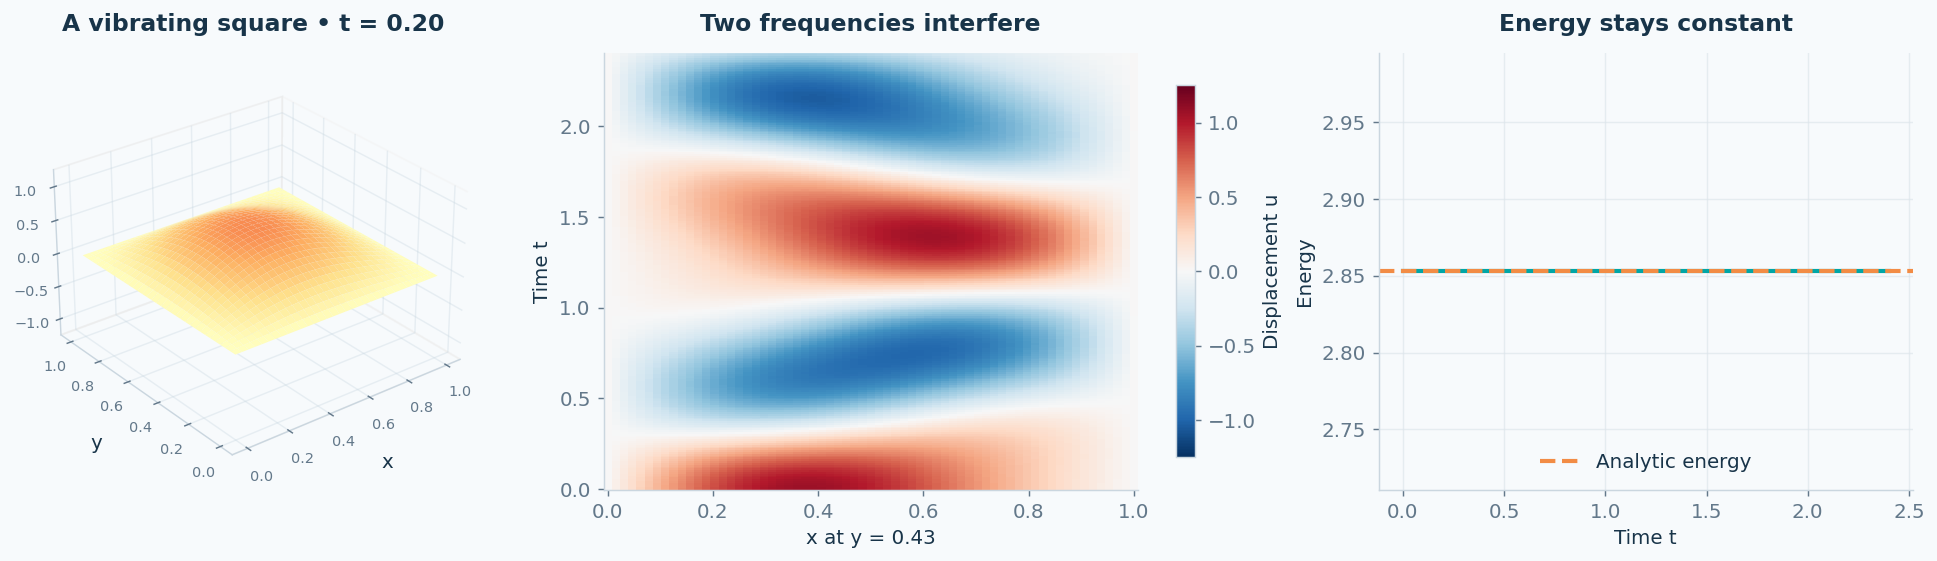

Maximum relative energy drift: 3.11e-16


In [4]:
wave_x = np.linspace(0, 1, 65)
wave_X, wave_Y = np.meshgrid(wave_x, wave_x)
wave_times = np.linspace(0, 2.4, 49)

def wave_state(t, x, y):
    return (np.sin(np.pi*x)*np.sin(np.pi*y)*np.cos(np.pi*np.sqrt(2)*t)
            + .25*np.sin(2*np.pi*x)*np.sin(np.pi*y)*np.cos(np.pi*np.sqrt(5)*t))

def wave_energy(t):
    ut = np.zeros_like(wave_X)
    ux, uy = ut.copy(), ut.copy()
    for amplitude, m, n in [(1., 1, 1), (.25, 2, 1)]:
        omega = np.pi*np.sqrt(m*m+n*n)
        ut -= amplitude*omega*np.sin(m*np.pi*wave_X)*np.sin(n*np.pi*wave_Y)*np.sin(omega*t)
        ux += amplitude*m*np.pi*np.cos(m*np.pi*wave_X)*np.sin(n*np.pi*wave_Y)*np.cos(omega*t)
        uy += amplitude*n*np.pi*np.sin(m*np.pi*wave_X)*np.cos(n*np.pi*wave_Y)*np.cos(omega*t)
    density = .5*(ut**2+ux**2+uy**2)
    return np.trapezoid(np.trapezoid(density, wave_x, axis=1), wave_x)

wave_E = np.array([wave_energy(t) for t in wave_times])
wave_E_exact = np.pi**2*(2+.25**2*5)/8
assert np.max(np.abs(wave_E-wave_E_exact))/wave_E_exact < 1e-10
fig = plt.figure(figsize=(15, 4.2), layout="constrained")
ax = fig.add_subplot(131, projection="3d")
ax.plot_surface(wave_X, wave_Y, wave_state(.2, wave_X, wave_Y), cmap="Spectral_r",
                vmin=-1.25, vmax=1.25, linewidth=0, antialiased=True)
style_3d(ax, "A vibrating square • t = 0.20")
ax.set(xlabel="x", ylabel="y", zlabel="u", zlim=(-1.25, 1.25))
ax = fig.add_subplot(132)
wave_T, wave_S = np.meshgrid(np.linspace(0, 2.4, 241), wave_x, indexing="ij")
im = ax.pcolormesh(wave_x, wave_T[:, 0], wave_state(wave_T, wave_S, .43),
                    cmap="RdBu_r", shading="auto", vmin=-1.25, vmax=1.25)
ax.set(title="Two frequencies interfere", xlabel="x at y = 0.43", ylabel="Time t")
fig.colorbar(im, ax=ax, label="Displacement u", shrink=.85)
ax = fig.add_subplot(133)
ax.plot(wave_times, wave_E, color=palette["teal"])
ax.axhline(wave_E_exact, color=palette["orange"], ls="--", label="Analytic energy")
ax.set(title="Energy stays constant", xlabel="Time t", ylabel="Energy",
       ylim=(.95*wave_E_exact, 1.05*wave_E_exact))
ax.grid(); ax.legend(loc="lower center")
save_figure(fig, "01_membrane")
print(f"Maximum relative energy drift: {np.ptp(wave_E)/wave_E_exact:.2e}")

In [5]:
wave_surface = lambda t: go.Surface(x=wave_X[::2, ::2], y=wave_Y[::2, ::2],
    z=wave_state(t, wave_X[::2, ::2], wave_Y[::2, ::2]),
    colorscale=wave_scale, cmin=-1.25, cmax=1.25,
    colorbar=dict(title="u"), contours=dict(z=dict(show=True, usecolormap=True,
    highlightcolor="white", project_z=True)))
wave_fig = go.Figure(data=[wave_surface(0)], frames=[
    go.Frame(data=[wave_surface(t)], name=f"{t:.2f}") for t in wave_times])
wave_fig.update_layout(title="Vibrating membrane · drag to rotate, press play",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis=dict(title="u", range=[-1.3, 1.3]),
               aspectratio=dict(x=1, y=1, z=.65), uirevision="membrane"),
    updatemenus=[dict(type="buttons", x=0, y=1.12, direction="left", buttons=[
        dict(label="▶ Play", method="animate", args=[None, dict(frame=dict(duration=65, redraw=True),
             transition=dict(duration=0), fromcurrent=True)]),
        dict(label="Pause", method="animate", args=[[None], dict(mode="immediate",
             frame=dict(duration=0, redraw=False), transition=dict(duration=0))])])],
    sliders=[dict(currentvalue=dict(prefix="Time t = "), steps=[dict(label=f"{t:.2f}",
        method="animate", args=[[f"{t:.2f}"], dict(mode="immediate",
        frame=dict(duration=0, redraw=True), transition=dict(duration=0))]) for t in wave_times])])
show_interactive(wave_fig, "01_membrane_interactive")

[Open interactive explorer](notebook_outputs/01_membrane_interactive.html) — open locally in a browser; GitHub previews show the static plots.

**Try:** change the second mode's amplitude, or its spatial indices $(m,n)$ together
with its frequency $\omega=\pi\sqrt{m^2+n^2}$. Does the interference pattern change
while energy stays conserved? What observations would distinguish the two modes?

## 2 · The same Poisson problem, two neural formulations

Solve $-u''=\pi^2\sin(\pi x)$, $u(0)=u(1)=0$.
Both models use $u_\theta=x(1-x)N_\theta(x)$, identical initial weights, and
Gauss–Legendre quadrature. The **PINN** minimizes the squared strong residual;
**Deep Ritz** minimizes
$$\mathcal E(v)=\int_0^1\left(\tfrac12|v'|^2-\pi^2\sin(\pi x)v\right)dx.$$
Use $u=\sin(\pi x)$ to check the error after training. We divide the PINN residual
by $\pi^2$ to scale the loss; the Ritz energy may be negative. Since the objectives
differ, compare the methods using **solution errors** on an independent grid.

In [6]:
class Poisson1D(nn.Module):
    def __init__(self, network, hard=True):
        super().__init__()
        self.net, self.hard = copy.deepcopy(network), hard
    def forward(self, x):
        raw = self.net(x)
        return x*(1-x)*raw if self.hard else raw

p1_nodes, p1_weights = np.polynomial.legendre.leggauss(128)
p1_qx = torch.tensor((.5*(p1_nodes+1))[:, None])
p1_qw = torch.tensor((.5*p1_weights)[:, None])
p1_grid = np.linspace(0, 1, 1001)
p1_exact = np.sin(np.pi*p1_grid)
p1_bc = torch.tensor([[0.], [1.]])
torch.manual_seed(SEED)
p1_initial = mlp(1, width=24)

def p1_objective(model, formulation="PINN", boundary_weight=1.):
    x = p1_qx.detach().requires_grad_()
    u = model(x)
    ux = grad_scalar(u, x)
    f = np.pi**2*torch.sin(np.pi*x)
    if formulation == "Ritz":
        return (p1_qw*(.5*ux.square()-f*u)).sum()
    uxx = grad_scalar(ux, x)
    loss = (p1_qw*((-uxx-f)/np.pi**2).square()).sum()
    if not model.hard:
        loss = loss + boundary_weight*model(p1_bc).square().mean()
    return loss

def p1_evaluate(model):
    x = torch.tensor(p1_grid[:, None], requires_grad=True)
    u = model(x)
    ux = grad_scalar(u, x)
    uxx = grad_scalar(ux, x)
    prediction = u.detach().numpy().ravel()
    residual = (-uxx-np.pi**2*torch.sin(np.pi*x)).detach().numpy().ravel()
    relative_l2 = np.sqrt(np.trapezoid((prediction-p1_exact)**2, p1_grid)
                          / np.trapezoid(p1_exact**2, p1_grid))
    return prediction, residual, float(relative_l2)

p1_models, p1_histories, p1_results = {}, {}, {}
for name, formulation in [("Hard PINN", "PINN"), ("Deep Ritz", "Ritz")]:
    model = Poisson1D(p1_initial)
    history = train_model(model, lambda: p1_objective(model, formulation),
              BUDGET["adam_1d"], BUDGET["lbfgs_1d"], diagnostic=lambda: p1_evaluate(model)[2])
    p1_models[name], p1_histories[name] = model, history
    p1_results[name] = p1_evaluate(model)
    metrics.append(dict(experiment=name, relative_l2=p1_results[name][2], seconds=history["seconds"]))
    assert np.max(np.abs(p1_results[name][0][[0,-1]])) == 0
    print(f"{name:12s} | relative L2 = {p1_results[name][2]:.3e} | {history['seconds']:.1f} s")

Hard PINN    | relative L2 = 3.725e-06 | 1.7 s


Deep Ritz    | relative L2 = 1.812e-05 | 1.0 s


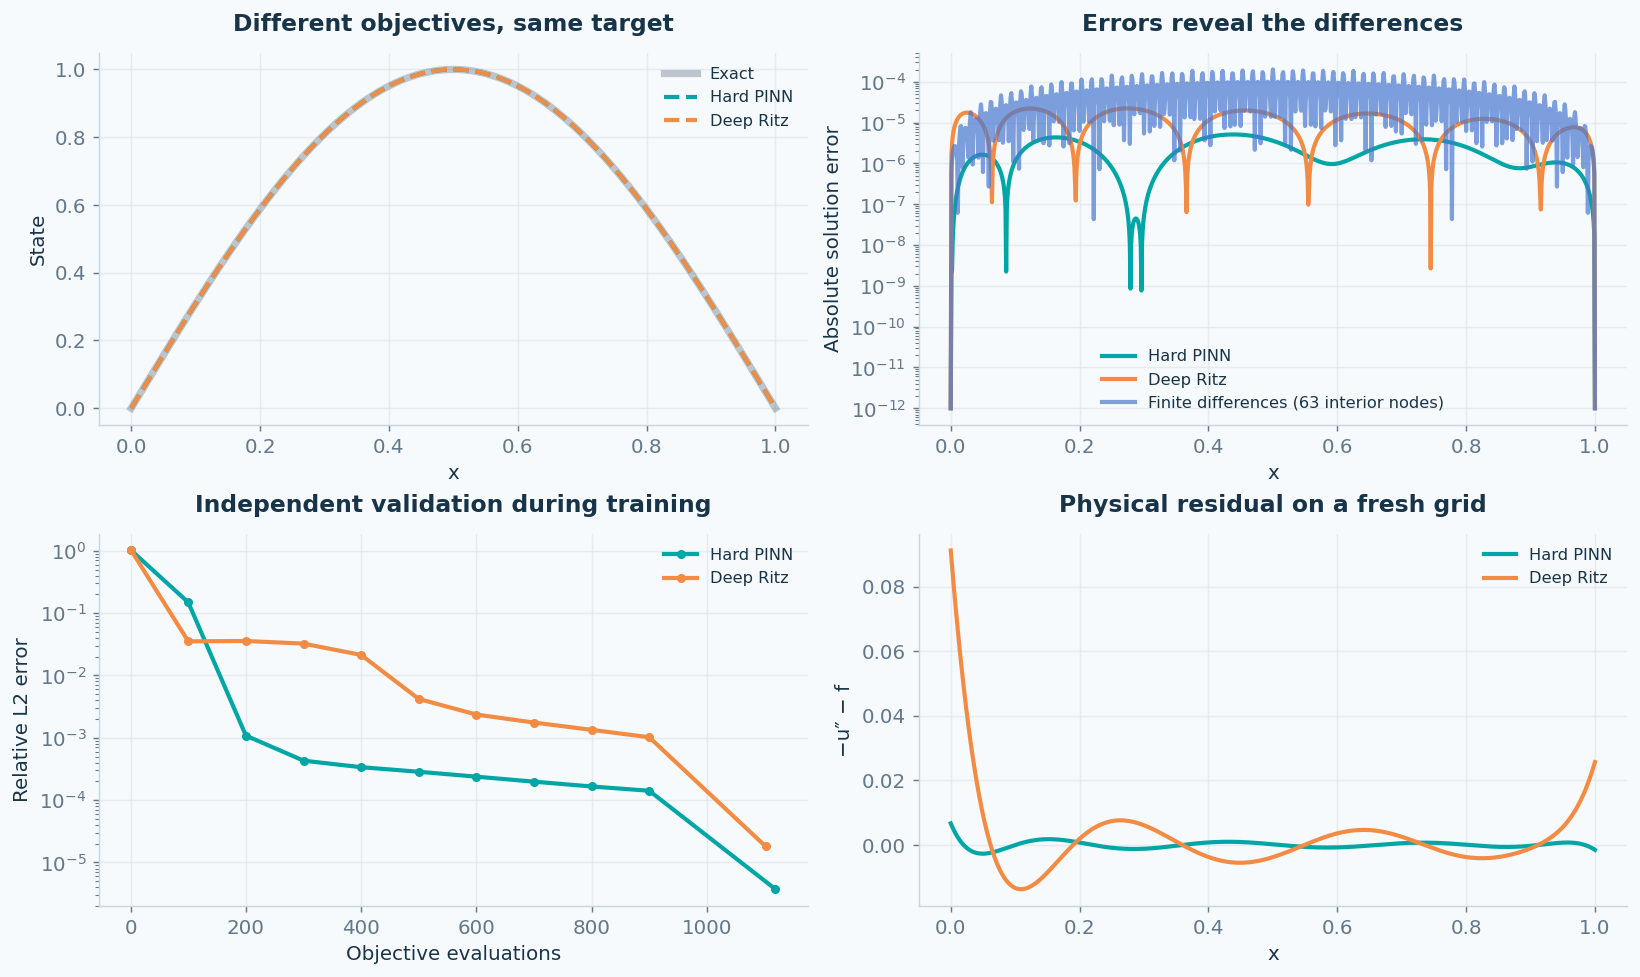

Finite-difference + linear interpolation relative L2 error: 8.985e-05


In [7]:
# A classical finite-difference reference; this is not an equal-cost benchmark.
p1_n = 63
p1_h = 1/(p1_n+1)
p1_fd_x = np.linspace(0, 1, p1_n+2)
p1_band = np.zeros((3, p1_n))
p1_band[0, 1:], p1_band[1], p1_band[2, :-1] = -1., 2., -1.
p1_fd_u = np.r_[0., solve_banded((1, 1), p1_band,
                      p1_h**2*np.pi**2*np.sin(np.pi*p1_fd_x[1:-1])), 0.]
p1_fd_interp = np.interp(p1_grid, p1_fd_x, p1_fd_u)
p1_fd_error = np.sqrt(np.trapezoid((p1_fd_interp-p1_exact)**2, p1_grid)
                       / np.trapezoid(p1_exact**2, p1_grid))
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.4), layout="constrained")
axes[0,0].plot(p1_grid, p1_exact, color=palette["navy"], lw=4, alpha=.25, label="Exact")
for name, colour in [("Hard PINN", palette["teal"]), ("Deep Ritz", palette["orange"])]:
    pred, residual, err = p1_results[name]
    hist = p1_histories[name]
    axes[0,0].plot(p1_grid, pred, color=colour, ls="--", label=name)
    axes[0,1].semilogy(p1_grid, np.maximum(np.abs(pred-p1_exact), 1e-12), color=colour, label=name)
    axes[1,0].semilogy(hist["error_eval"], hist["error"], "o-", color=colour, ms=4, label=name)
    axes[1,1].plot(p1_grid, residual, color=colour, label=name)
axes[0,1].semilogy(p1_grid, np.maximum(np.abs(p1_fd_interp-p1_exact), 1e-12),
                  color=palette["blue"], alpha=.7, label="Finite differences (63 interior nodes)")
axes[0,0].set(title="Different objectives, same target", xlabel="x", ylabel="State")
axes[0,1].set(title="Errors reveal the differences", xlabel="x", ylabel="Absolute solution error")
axes[1,0].set(title="Independent validation during training", xlabel="Objective evaluations", ylabel="Relative L2 error")
axes[1,1].set(title="Physical residual on a fresh grid", xlabel="x", ylabel="−u″ − f")
for ax in axes.ravel():
    ax.grid(); ax.legend(fontsize=9)
save_figure(fig, "02_pinn_vs_ritz")
print(f"Finite-difference + linear interpolation relative L2 error: {p1_fd_error:.3e}")

The model with the smaller strong residual may have the larger solution error.
Ritz targets the energy norm. The figure also includes a finite-difference solution;
its node count and interpolation are listed so you can repeat the comparison.
Try other seeds and training budgets to see how the results change.

## 3 · Boundary penalties: the weight changes the optimization problem

Compare soft constraints
$$\widehat{\mathcal J}_\lambda
=\widehat{\mathcal J}_r+\lambda\,\tfrac12\bigl(|u_\theta(0)|^2+|u_\theta(1)|^2\bigr)$$
with the hard factor $x(1-x)$. Every run starts from the same raw weights and receives
the same number of **Adam updates**, with no L-BFGS refinement. Large penalty
weights can change training priorities and conditioning.

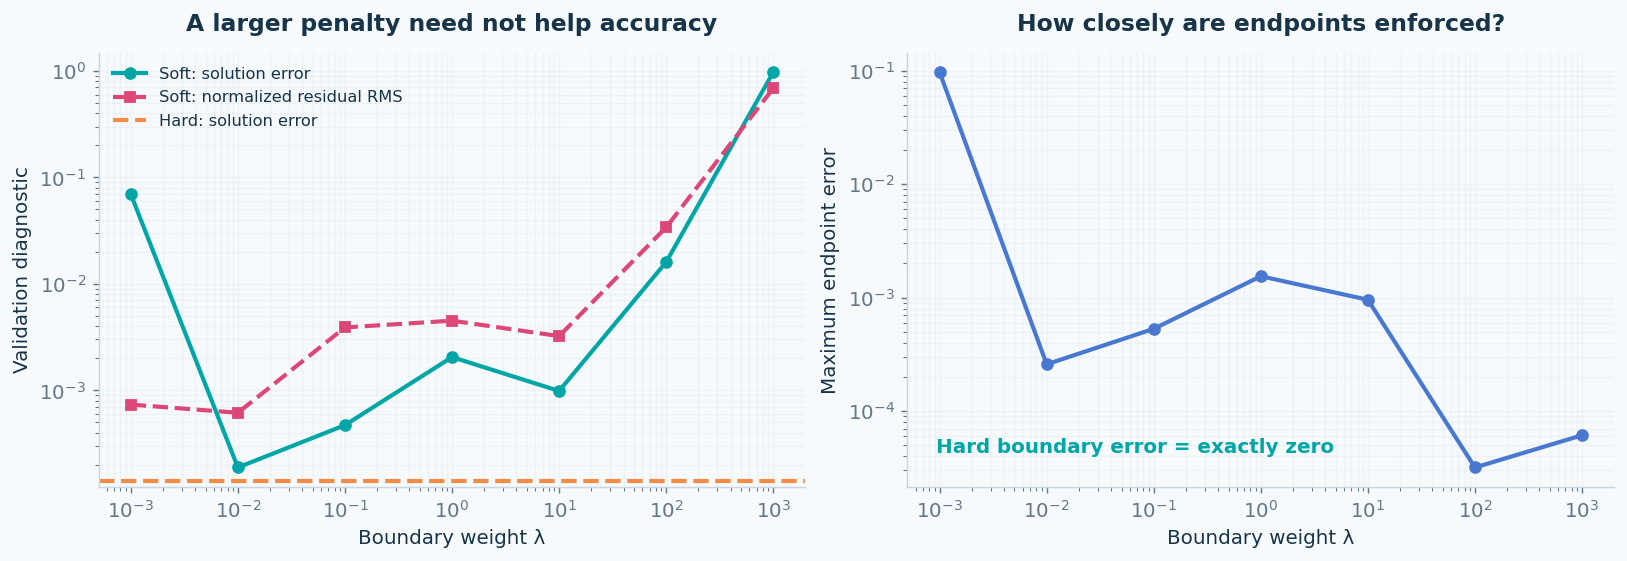

In [8]:
p1_lambdas = np.logspace(-3, 3, 7)
p1_sweep = []
for p1_lam in p1_lambdas:
    model = Poisson1D(p1_initial, hard=False)
    train_model(model, lambda: p1_objective(model, boundary_weight=p1_lam), BUDGET["boundary_adam"])
    pred, residual, relerr = p1_evaluate(model)
    p1_sweep.append((relerr, np.max(np.abs(pred[[0,-1]])),
                     np.sqrt(np.trapezoid(residual**2, p1_grid))/np.pi**2))
p1_hard_adam = Poisson1D(p1_initial)
train_model(p1_hard_adam, lambda: p1_objective(p1_hard_adam), BUDGET["boundary_adam"])
p1_hard_adam_result = p1_evaluate(p1_hard_adam)
p1_sweep = np.asarray(p1_sweep)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2), layout="constrained")
axes[0].loglog(p1_lambdas, p1_sweep[:,0], "o-", color=palette["teal"], label="Soft: solution error")
axes[0].loglog(p1_lambdas, p1_sweep[:,2], "s--", color=palette["pink"], label="Soft: normalized residual RMS")
axes[0].axhline(p1_hard_adam_result[2], color=palette["orange"], ls="--", label="Hard: solution error")
axes[1].loglog(p1_lambdas, p1_sweep[:,1], "o-", color=palette["blue"])
axes[1].text(.04,.08,"Hard boundary error = exactly zero", transform=axes[1].transAxes,
             color=palette["teal"], weight="bold")
axes[0].set(title="A larger penalty need not help accuracy", xlabel="Boundary weight λ", ylabel="Validation diagnostic")
axes[1].set(title="How closely are endpoints enforced?", xlabel="Boundary weight λ", ylabel="Maximum endpoint error")
for ax in axes: ax.grid(which="both", alpha=.35)
axes[0].legend(fontsize=9)
save_figure(fig, "03_boundary_balance")

**Try:** increase the optimization budget or repeat with another seed. Does the preferred
weight change? These runs stop after a fixed number of updates, so they may not
reach the minimum of the penalized loss.

## Save this notebook's results

This cell records versions, settings, diagnostics and computed fields, and builds a
local gallery. Report filenames include this notebook's part number, so notebooks
can run independently in any order without overwriting each other's reports.

In [9]:
# Keep reports separate so running one notebook cannot replace another's results.
PART = '01_foundations'
summary_metrics = list(metrics)

report = dict(part=PART, versions=versions, run_mode=RUN_MODE, seed=SEED, budgets=BUDGET,
    device="cpu", dtype=str(torch.get_default_dtype()), settings=dict(wave_relative_energy_drift=float(np.ptp(wave_E)/wave_E_exact)),
    static_figures=FIGURE_NAMES, interactive_figures=INTERACTIVE_NAMES,
    metrics=summary_metrics, elapsed_seconds=time.perf_counter()-NOTEBOOK_START)
(OUTPUT_DIR / f"run_summary_{PART}.json").write_text(json.dumps(report, indent=2))
np.savez_compressed(OUTPUT_DIR / f"computed_fields_{PART}.npz", boundary_weights=p1_lambdas, boundary_diagnostics=p1_sweep,
        wave_times=wave_times, wave_energy=wave_E,
        poisson_x=p1_grid, poisson_exact=p1_exact,
        pinn_prediction=p1_results["Hard PINN"][0],
        ritz_prediction=p1_results["Deep Ritz"][0])

from html import escape
cards = []
for name in FIGURE_NAMES:
    title = escape(name.replace("_", " ").title())
    cards.append(f'<figure><a href="{name}.png"><img src="{name}.png" alt="{title}"></a>'
                 f'<figcaption>{title} · <a href="{name}.pdf">PDF</a></figcaption></figure>')
links = "".join(f'<li><a href="{name}.html">{escape(name.replace("_", " ").title())}</a></li>'
                for name in INTERACTIVE_NAMES)
page = ('<!doctype html><html lang="en"><meta charset="utf-8">'
        '<meta name="viewport" content="width=device-width, initial-scale=1">'
        '<title>Neural PDE Laboratory</title><style>'
        'body{font-family:system-ui;color:#273442;max-width:1100px;margin:auto;padding:32px}'
        'img{max-width:100%}figure{margin:32px 0}a{color:#4d708a}</style>'
        f'<h1>Neural PDE Laboratory · {escape(PART)}</h1><ul>' + links + '</ul>' + "".join(cards) + '</html>')
(OUTPUT_DIR / f"index_{PART}.html").write_text(page)
print(f"Completed in {report['elapsed_seconds']:.1f} seconds.")
print(f"Saved {len(FIGURE_NAMES)} figure sets and {len(INTERACTIVE_NAMES)} interactive explorers.")
print(f"Reports: run_summary_{PART}.json, computed_fields_{PART}.npz, index_{PART}.html")
for row in summary_metrics:
    print(f"{row['experiment']:32s} relative L2 = {row['relative_l2']:.3e}")

Completed in 17.9 seconds.
Saved 3 figure sets and 1 interactive explorers.
Reports: run_summary_01_foundations.json, computed_fields_01_foundations.npz, index_01_foundations.html
Hard PINN                        relative L2 = 3.725e-06
Deep Ritz                        relative L2 = 1.812e-05


[Laboratory index](Neural_PDE_Laboratory.ipynb) · [Next notebook](Neural_PDE_02_poisson_and_limits.ipynb)